In [217]:
from brian2 import *
import matplotlib.pyplot as plt
from plottingTools import *

In [218]:
class Gaussian_Input_Generator:
    def __init__(self,
                 n,
                 amp=0,
                 mu=0,
                 sigma=1,
                 noise=False,
                 normalised=True,
                 verbose=0):
        
        self.n=n
        self.m=amp  #amplitude
        self.mu=mu #peak position (preferred direction of the corresponding neuron (theta in gradi))
        self.sigma=sigma #refers to the certainty of the cue
        self.noise=noise
        self.normalised=normalised
        self.x=np.linspace(0, 360, self.n, endpoint=True)
        self.y=None
        self.verbose=verbose
        
        self.adjusted_mu = self.mu % 360
        self.ground_truth_index = int((self.adjusted_mu/360)*self.n)      # Find the ground truth neuron index        

    def generate_cue(self):
    
        # Create a wrap based on the number of neurons
        wraps = np.arange(-self.n/2, self.n/2+1)
        gaussianComponent = np.exp(-0.5 * ((self.x[:,np.newaxis]-self.mu+wraps*360) /self.sigma)**2)
        wrappedGaussian = self.m * np.sum(gaussianComponent, axis=1)
        normalizationTerm=(self.sigma*((2*pi)**0.5))

        y=wrappedGaussian
        
        if self.noise:
            y=self.add_noise(y)
            
        if self.normalised:
            y=y/normalizationTerm
        
        if self.verbose==1:
            print('Theoretical Angle:', self.adjusted_mu,'\tTheoretical Neuron Index:', self.ground_truth_index,
                  '\n Estimated Angle:', self.x[np.argmax(y)], '\t Estimated Neuron:', np.argmax(y), end='\n')
        if self.verbose==2:
            print('Theoretical Angle:', self.adjusted_mu,'\tTheoretical Neuron Index:', self.ground_truth_index,
                  '\nEstimated Angle:', self.x[np.argmax(y)], '\t Estimated Neuron Index:', np.argmax(y), end='\n')
            for index, (angle, value) in enumerate(zip(self.x, y)):
                print('Gaussian', index, 'at', angle, 'has value', value)
        
        self.y = y
        return y
    
    def plot_gaussians_polar(self):
        # Generate the wrapped Gaussian values
        gaussian_values = self.generate_cue()
        
        plot_on_circle(self.x, gaussian_values, title='Wrapped Gaussian on a Circle',
                       legend_label='Wrapped Gaussian', legend_kwargs={'loc': 'upper right'})

    def add_noise(self,I):
        I_noisy=I+normal(0,1,len(self.x))*2e-2
        return I_noisy
    
    def peak_position(self):
        return self.x[np.argmax(self.y)]
    
    def to_brian2_neuron_group(self, peak_only=False):
        if peak_only:
            input_gen = NeuronGroup(1, 'I : 1', threshold='I > 0', reset='I = 0', method='exact')
            input_gen.I = 1
            return input_gen, self.ground_truth_index
        else:
            input_gen = NeuronGroup(self.n, 'I : 1', threshold='I > 0', reset='I = 0', method='exact')
            if self.y is None:
                input_gen.I = self.generate_cue()
            else:
                input_gen.I = self.y
            return input_gen

Theoretical Angle: 10 	Theoretical Neuron Index: 3 
 Estimated Angle: 9.07563025210084 	 Estimated Neuron: 3


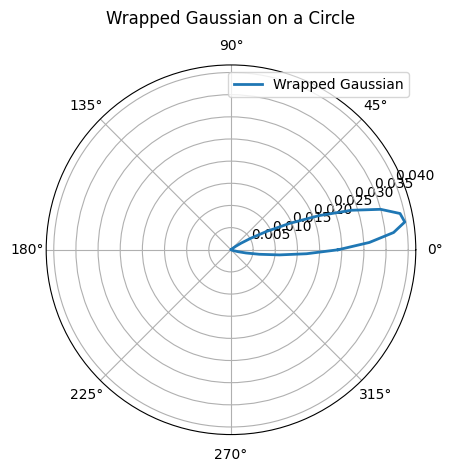

In [219]:
num_neurons = 120
duration = 100*ms

gaussian_gen = Gaussian_Input_Generator(num_neurons, amp=1, mu=10, sigma=10, noise=False, normalised=True, verbose=1)
gaussian_gen.plot_gaussians_polar()

In [220]:
input_gen, NeuronIndex = gaussian_gen.to_brian2_neuron_group(peak_only=True)
print(NeuronIndex)
spike_monitor_input = SpikeMonitor(input_gen, name="spike_input")
run(duration)
print(spike_monitor_input.count)

3
<spike_input.count: array([1], dtype=int32)>


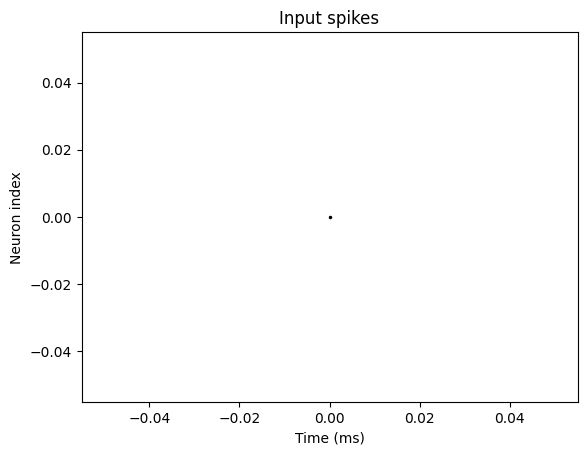

In [221]:
# plotting
plt.figure()
plt.plot(spike_monitor_input.t/ms, spike_monitor_input.i, '.k', ms=3)
plt.xlabel('Time (ms)')
plt.ylabel('Neuron index')
plt.title('Input spikes')
plt.show()